#  Data Analytics & Forecast: Inteligência de Negócios para Studio de Tattoo
**Autor:** Jonathas Fernandes  
**Expertise:** Senior Web Developer | Data Analyst | Lean Six Sigma Green Belt

---

##  1. Visão Geral do Projeto
Este projeto demonstra a construção de um ecossistema de dados **end-to-end** dentro do Databricks. O objetivo principal é transformar registos operacionais brutos de um estúdio de tatuagem em **previsibilidade financeira** e **estratégia comercial**, permitindo uma transição da gestão por intuição para a **gestão orientada por dados (Data-Driven)**.

##  Stack Tecnológica
* **Processamento de Dados:** PySpark (Spark SQL) para escalabilidade.
* **Armazenamento:** Delta Lake (Implementação de Arquitetura Medalhão - Camada Silver).
* **Linguagem:** Python.
* **Modelagem Estatística:** SARIMA (Seasonal Autoregressive Integrated Moving Average) para Forecast.
* **Ambiente:** Databricks.

## Diferenciais Estratégicos Implementados
* **Engenharia de Dados Sênior:** Normalização robusta de caracteres e tratamento de tipos financeiros via Regex.
* **Conformidade LGPD:** Implementação de funções de anonimização para dados sensíveis (WhatsApp), garantindo a privacidade dos clientes.
* **Governança de Dados:** Persistência em tabelas Delta para garantir integridade, suporte a cargas incrementais e controle de versão (Time Travel).
* **Machine Learning & Forecast:** Modelagem de sazonalidade para prever picos de faturamento e auxiliar na gestão de caixa.

##  Impactos no Negócio
Com este pipeline, o gestor consegue responder a perguntas críticas:
1.  **Qual a projeção de faturamento para 2026?** (Baseado no modelo SARIMA).
2.  **Qual o principal gargalo do funil de vendas?** (Identificação de motivos de perda de leads).
3.  **Qual estilo de tatuagem gera maior retorno?** (Análise de mix de produtos e ticket médio).

---

In [0]:

# 1. Spark Context e Funções (Processamento Distribuído)
from pyspark.sql import functions as F
from pyspark.sql import Window, types as T

# 2. Manipulação de Strings e Limpeza
import re
from unicodedata import normalize

# 3. Análise Estatística e Forecast (Processamento Local)
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 4. Visualização
import matplotlib.pyplot as plt
import seaborn as sns 

#  Definir o timezone e locale logo no início
spark.conf.set("spark.sql.session.timeZone", "UTC")

In [0]:
# 1. Definição da função de normalização
def normalize_column_name(name):
    name = name.lower().strip()
    name = normalize('NFKD', name).encode('ASCII', 'ignore').decode('ASCII')
    name = re.sub(r'[ \-]+', '_', name)
    name = re.sub(r'[^a-z0-9_]', '', name)
    return name

# 2. Ingestão e Processamento
path_final = "/Volumes/workspace/default/new_vol/Domingos Tatoo.csv"

try:
    df_raw = spark.read.format("csv") \
        .option("header", "true") \
        .option("sep", ";") \
        .option("inferSchema", "true") \
        .load(path_final)

    # Normalização dos nomes de colunas
    for col_name in df_raw.columns:
        df_raw = df_raw.withColumnRenamed(col_name, normalize_column_name(col_name))

    # Tratamento Colunas Valor Financeiro 
    cols_financeiras = ["total", "sinal", "valor_procedimento", "valor_desconto"]
    for c in cols_financeiras:
        if c in df_raw.columns:
            df_raw = df_raw.withColumn(c, 
                F.regexp_replace(F.col(c), r"[R\$\s]", "")
            ).withColumn(c,
                F.regexp_replace(F.col(c), r"\.", "")
            ).withColumn(c,
                F.regexp_replace(F.col(c), ",", ".").cast("double")
            )

    # Tratamento Padronização WhatsApp e Anonimização (LGPD)
    if "whatsapp" in df_raw.columns:
        df_raw = df_raw.withColumn("whatsapp", F.regexp_replace(F.col("whatsapp"), r"\D", ""))
        # Criando coluna mascarada para prints/LinkedIn
        df_raw = df_raw.withColumn("whatsapp_anon", F.concat(F.substring(F.col("whatsapp"), 1, 4), F.lit("*****")))

    # Datas e Filtro a partir de 2024
    if "data_do_atendimento" in df_raw.columns:
        df_raw = df_raw.withColumn("data_do_atendimento", F.to_date(F.col("data_do_atendimento")))
        df_raw = df_raw.filter(F.col("data_do_atendimento") >= "2024-01-01")
        
    # Ajuste 'motivo_nao_venda' para o nome exato da sua segunda coluna da imagem se for diferente
    df_raw = df_raw.na.fill({
        "estilo": "Não Informado",
        "origem": "Não Informado",
        "resultado": "Não Informado",
        "motivo_nao_venda": "Não Informado" 
    })
    # Filtro de data apartir de 2024
    df_raw = df_raw.filter(F.col("data_do_atendimento") >= "2024-01-01")

    # --- BIFURCAÇÃO DOS DADOS ---

    # DataFrame 1: Apenas Vendas Concluídas (Para Projeção e YoY)
    df_vendas = df_raw.filter(F.col("resultado") == "Venda")

    # DataFrame 2: Apenas Oportunidades Perdidas (Para Análise de Churn/Motivos)
    df_perdas = df_raw.filter(F.col("resultado") != "Venda")

    # Ordenação Geral para conferência
    df_vendas = df_vendas.orderBy(F.col("data_do_atendimento").desc())

    print(f"Base Processada: {df_vendas.count()} Vendas e {df_perdas.count()} Orçamentos perdidos.")
    display(
        df_vendas.select(
            "data_do_atendimento",
            "nome_cliente",
            "whatsapp_anon",
            "estilo",
            "total"
        ).limit(5)
    )
            


except Exception as e:
    print(f"Erro no processamento: {e}")

Base Processada: 468 Vendas e 6226 Orçamentos perdidos.


data_do_atendimento,nome_cliente,whatsapp_anon,estilo,total
2026-04-16,Jéssica Santos,1999*****,Realismo preto e cinza,2300.0
2026-04-15,Marcelo,1999*****,Não Informado,990.0
2026-04-13,Vnicius,1999*****,Realismo preto e cinza,1400.0
2026-04-13,Rafael,1194*****,Realismo preto e cinza,1300.0
2026-04-02,Sidney,1193*****,Religiosa,1500.0


In [0]:
# 1. Cria o 'banco de dados' silver caso ele não exista
spark.sql("CREATE DATABASE IF NOT EXISTS silver")

# 2. Salvando a TBL
df_raw.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("silver.tabela_domingues_tatoo")

print(f"Tabela silver.tabela_domingues_tatoo salva com sucesso!")

Tabela silver.tabela_domingues_tatoo salva com sucesso!


In [0]:
#  Resumo financeiro por Estilo 
print("💰 TOP 10 ESTILOS POR FATURAMENTO:")
window_estilo = Window.partitionBy()

df_estilo = df_vendas.groupBy("estilo") \
    .agg(
        F.sum("total").alias("faturamento"),
        F.count("total").alias("qtd_vendas"),
        F.round(F.avg("total"), 2).alias("ticket_medio")
    ) \
    .withColumn("pct_faturamento", F.round((F.col("faturamento") / F.sum("faturamento").over(window_estilo)) * 100, 2)) \
    .orderBy(F.desc("faturamento"))

df_estilo.show(10)

# Análise de Origem
print("📣 PERFORMANCE POR ORIGEM:")
df_origem = df_vendas.groupBy("origem") \
    .agg(
        F.sum("total").alias("total_gerado"),
        F.count("total").alias("qtd_vendas"),
        F.round(F.avg("total"), 2).alias("ticket_medio_canal")
    ) \
    .orderBy(F.desc("total_gerado"))

df_origem.show(10)

# Funil de Conversão 
print("📊 TAXA DE CONVERSÃO GERAL:")
total_leads = df_raw.count()
df_funil = df_raw.groupBy("resultado") \
    .agg(F.count("*").alias("qtd")) \
    .withColumn("taxa_conversao_pct", F.round((F.col("qtd") / total_leads) * 100, 1)) \
    .orderBy(F.desc("qtd"))

df_funil.show(10)

# Insight de Perda
print(" ANÁLISE DE PERDAS (MOTIVOS):")
df_motivos_perda = df_perdas.groupBy("motivo_nao_venda") \
    .agg(
        F.count("*").alias("qtd_ocorrencias"),
        F.sum("total").alias("valor_em_risco")
    ) \
    .withColumn("pct_ocorrencias", F.round((F.col("qtd_ocorrencias") / F.sum("qtd_ocorrencias").over(Window.partitionBy())) * 100, 2)) \
    .orderBy(F.desc("qtd_ocorrencias"))

df_motivos_perda.show(10)

💰 TOP 10 ESTILOS POR FATURAMENTO:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+--------------------+-----------+----------+------------+---------------+
|              estilo|faturamento|qtd_vendas|ticket_medio|pct_faturamento|
+--------------------+-----------+----------+------------+---------------+
|Realismo preto e ...|   286356.0|       167|     1714.71|          41.91|
|       Não Informado|   142770.0|        89|     1604.16|          20.89|
|     Realismo animal|    67770.0|        48|     1411.88|           9.92|
|           Delicadas|    46347.5|        60|      772.46|           6.78|
|           Cobertura|    40500.0|        29|     1396.55|           5.93|
|             Reforma|    35370.0|        21|     1684.29|           5.18|
|              Outros|    30625.0|        26|     1177.88|           4.48|
|            Oriental|     7440.0|         5|      1488.0|           1.09|
|               Maori|     6990.0|         4|      1747.5|           1.02|
|       Desenho comum|     4735.0|         7|      676.43|           0.69|
+--------------------+---

In [0]:
# Base Mensal
df_mensal = df_vendas.withColumn("ano", F.year("data_do_atendimento")) \
                      .withColumn("mes", F.month("data_do_atendimento")) \
                      .groupBy("ano", "mes") \
                      .agg(F.round(F.sum("total"), 2).alias("faturamento"))

# Janela para YoY 
window_yoy = Window.partitionBy("mes").orderBy("ano")

# Janela para YTD 
window_ytd = Window.partitionBy("ano").orderBy("mes").rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Cálculo das Métricas
df_final = df_mensal \
    .withColumn("faturam_ano_anterior", F.lag("faturamento").over(window_yoy)) \
    .withColumn("crescimento_yoy_pct", 
        F.round(
            F.when(F.col("faturam_ano_anterior") > 0, 
                ((F.col("faturamento") - F.col("faturam_ano_anterior")) / 
                 F.col("faturam_ano_anterior")) * 100
            ).otherwise(0), 1)
    ) \
    .withColumn("faturamento_ytd", 
        F.round(F.sum("faturamento").over(window_ytd), 1)
    ) \
    .orderBy("ano", "mes")
# Agrupando o faturamento por Ano
df_anual = df_vendas.withColumn("ano", F.year("data_do_atendimento")) \
    .groupBy("ano") \
    .agg(
        F.round(F.sum("total"), 2).alias("faturamento_anual"),
        F.count("total").alias("qtd_vendas"),
        F.round(F.avg("total"), 2).alias("ticket_medio")
    ) \
    .orderBy("ano")

# Janela para calcular a variação anual (YoY Anual)
window_anual = Window.orderBy("ano")

df_evolucao_anual = df_anual \
    .withColumn("faturam_ano_anterior", F.lag("faturamento_anual").over(window_anual)) \
    .withColumn("crescimento_anual_pct", 
        F.round(
            F.when(F.col("faturam_ano_anterior") > 0, 
                ((F.col("faturamento_anual") - F.col("faturam_ano_anterior")) / 
                 F.col("faturam_ano_anterior")) * 100
            ).otherwise(0), 1)
    )

print(" EVOLUÇÃO MACRO: FECHAMENTO ANUAL E CRESCIMENTO")
df_evolucao_anual.select("ano", "faturamento_anual", "qtd_vendas", "ticket_medio", "crescimento_anual_pct").show()

print(" ANÁLISE ESTRATÉGICA: YoY (CRESCIMENTO ANUAL) E YTD (ACUMULADO)")
df_final.filter(F.col("ano") >= 2025).select("ano", "mes", "faturamento", "faturam_ano_anterior", "crescimento_yoy_pct", "faturamento_ytd").show(36)

 EVOLUÇÃO MACRO: FECHAMENTO ANUAL E CRESCIMENTO
+----+-----------------+----------+------------+---------------------+
| ano|faturamento_anual|qtd_vendas|ticket_medio|crescimento_anual_pct|
+----+-----------------+----------+------------+---------------------+
|2024|         269696.0|       173|     1558.94|                  0.0|
|2025|         310557.5|       236|     1315.92|                 15.2|
|2026|         103090.0|        58|     1777.41|                -66.8|
+----+-----------------+----------+------------+---------------------+

 ANÁLISE ESTRATÉGICA: YoY (CRESCIMENTO ANUAL) E YTD (ACUMULADO)
+----+---+-----------+--------------------+-------------------+---------------+
| ano|mes|faturamento|faturam_ano_anterior|crescimento_yoy_pct|faturamento_ytd|
+----+---+-----------+--------------------+-------------------+---------------+
|2025|  1|    25610.0|             18445.0|               38.8|        25610.0|
|2025|  2|    16280.0|             28671.0|              -43.2|       

In [0]:
# PREPARAÇÃO E TREINO DO MODELO (SARIMA)
# Filtro de meses fechados até Março/26 para não enviesar com o mês atual incompleto
df_treino = df_final.filter((F.col("faturamento") > 0) & 
                            ((F.col("ano") < 2026) | (F.col("mes") < 4))) \
                    .select("ano", "mes", "faturamento") \
                    .orderBy("ano", "mes") \
                    .toPandas()

df_treino['data'] = pd.to_datetime(df_treino['ano'].astype(str) + '-' + df_treino['mes'].astype(str) + '-01')
df_treino = df_treino.set_index('data').asfreq('MS')

# Configuração Sênior do SARIMA (p,d,q) x (P,D,Q,s)
modelo = SARIMAX(df_treino['faturamento'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False, enforce_invertibility=False)
resultado_sarima = modelo.fit(disp=False)

#PROJEÇÃO (Abr/26 a Dez/26)
pred_media = resultado_sarima.get_forecast(steps=9).predicted_mean

# CONSOLIDAÇÃO DA BASE TOTAL
df_hist = df_treino.copy()
df_proj = pd.DataFrame({'faturamento': pred_media.values}, index=pred_media.index)
df_total = pd.concat([df_hist[['faturamento']], df_proj])
df_total['tipo'] = ['Real' if x in df_hist.index else 'Projeção' for x in df_total.index]
df_total['variacao_pct'] = df_total['faturamento'].pct_change() * 100

# Filtro para visualização no gráfico (Abr/25 em diante)
df_view = df_total[df_total.index >= '2025-04-01'].copy()

# PROCESSAMENTO DAS TABELAS DE RESUMO 

# Visão Anual
df_anual_consolidado = df_total.copy()
df_anual_consolidado['ano'] = df_anual_consolidado.index.year

tabela_anual = df_anual_consolidado.groupby('ano').agg(
    faturamento_total=('faturamento', 'sum'),
    status=('tipo', lambda x: 'Consolidado' if all(x == 'Real') else 'Estimado (Real + Proj.)')
)
tabela_anual['Crescimento YoY'] = tabela_anual['faturamento_total'].pct_change() * 100

# Visão Mensal Formatada
df_tabela_mensal = df_view.copy()
df_tabela_mensal['Período'] = df_tabela_mensal.index.strftime('%b/%y')
df_tabela_mensal['Faturamento_Fmt'] = df_tabela_mensal['faturamento'].apply(lambda x: f"R$ {x/1000:,.1f}k")
df_tabela_mensal['Variação MoM'] = df_tabela_mensal['variacao_pct'].apply(
    lambda x: f"▲ {x:.1f}%" if x > 0 else (f"▼ {x:.1f}%" if x < 0 else "-")
)

# OUTPUT EXECUTIVO FINAL

print("=" * 75)
print(" RELATÓRIO EXECUTIVO: PERFORMANCE HISTÓRICA & PREVISÃO 2026")
print("=" * 75)

# Tabela Macro
for ano, row in tabela_anual.iterrows():
    evolucao = f"({row['Crescimento YoY']:+.1f}%)" if pd.notna(row['Crescimento YoY']) else "   -   "
    print(f"FECHAMENTO {ano}: R$ {row['faturamento_total']/1000:>6.1f}k {evolucao:<8} | Status: {row['status']}")

# Insight Principal
faturam_25 = tabela_anual.loc[2025, 'faturamento_total']
faturam_26 = tabela_anual.loc[2026, 'faturamento_total']
diff_pct = ((faturam_26 - faturam_25) / faturam_25) * 100

print("-" * 75)
print(f" INSIGHT: Projeção de crescimento de {diff_pct:.1f}% para 2026 vs 2025.")
print("-" * 75)

# Tabela Detalhada
print("\n📊 DETALHAMENTO MENSAL (Evolução e Forecast):")
print(df_tabela_mensal[['Período', 'Faturamento_Fmt', 'Variação MoM', 'tipo']].to_string(index=False))
print("=" * 75)


 RELATÓRIO EXECUTIVO: PERFORMANCE HISTÓRICA & PREVISÃO 2026
FECHAMENTO 2024: R$  269.7k    -     | Status: Consolidado
FECHAMENTO 2025: R$  310.6k (+15.2%) | Status: Consolidado
FECHAMENTO 2026: R$  446.3k (+43.7%) | Status: Estimado (Real + Proj.)
---------------------------------------------------------------------------
 INSIGHT: Projeção de crescimento de 43.7% para 2026 vs 2025.
---------------------------------------------------------------------------

📊 DETALHAMENTO MENSAL (Evolução e Forecast):
Período Faturamento_Fmt Variação MoM     tipo
 Apr/25        R$ 17.1k       ▲ 3.5%     Real
 May/25        R$ 37.2k     ▲ 118.2%     Real
 Jun/25        R$ 24.1k     ▼ -35.2%     Real
 Jul/25        R$ 32.8k      ▲ 35.9%     Real
 Aug/25        R$ 25.7k     ▼ -21.6%     Real
 Sep/25        R$ 28.1k       ▲ 9.1%     Real
 Oct/25        R$ 31.3k      ▲ 11.7%     Real
 Nov/25        R$ 26.1k     ▼ -16.6%     Real
 Dec/25        R$ 29.7k      ▲ 13.6%     Real
 Jan/26        R$ 36.2k      ▲ 

/local_disk0/.ephemeral_nfs/envs/pythonEnv-60994e0a-b24c-4a5b-ae00-50715efd9972/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/local_disk0/.ephemeral_nfs/envs/pythonEnv-60994e0a-b24c-4a5b-ae00-50715efd9972/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:1235: RuntimeWarning: invalid value encountered in divide
  np.inner(score_obs, score_obs) /


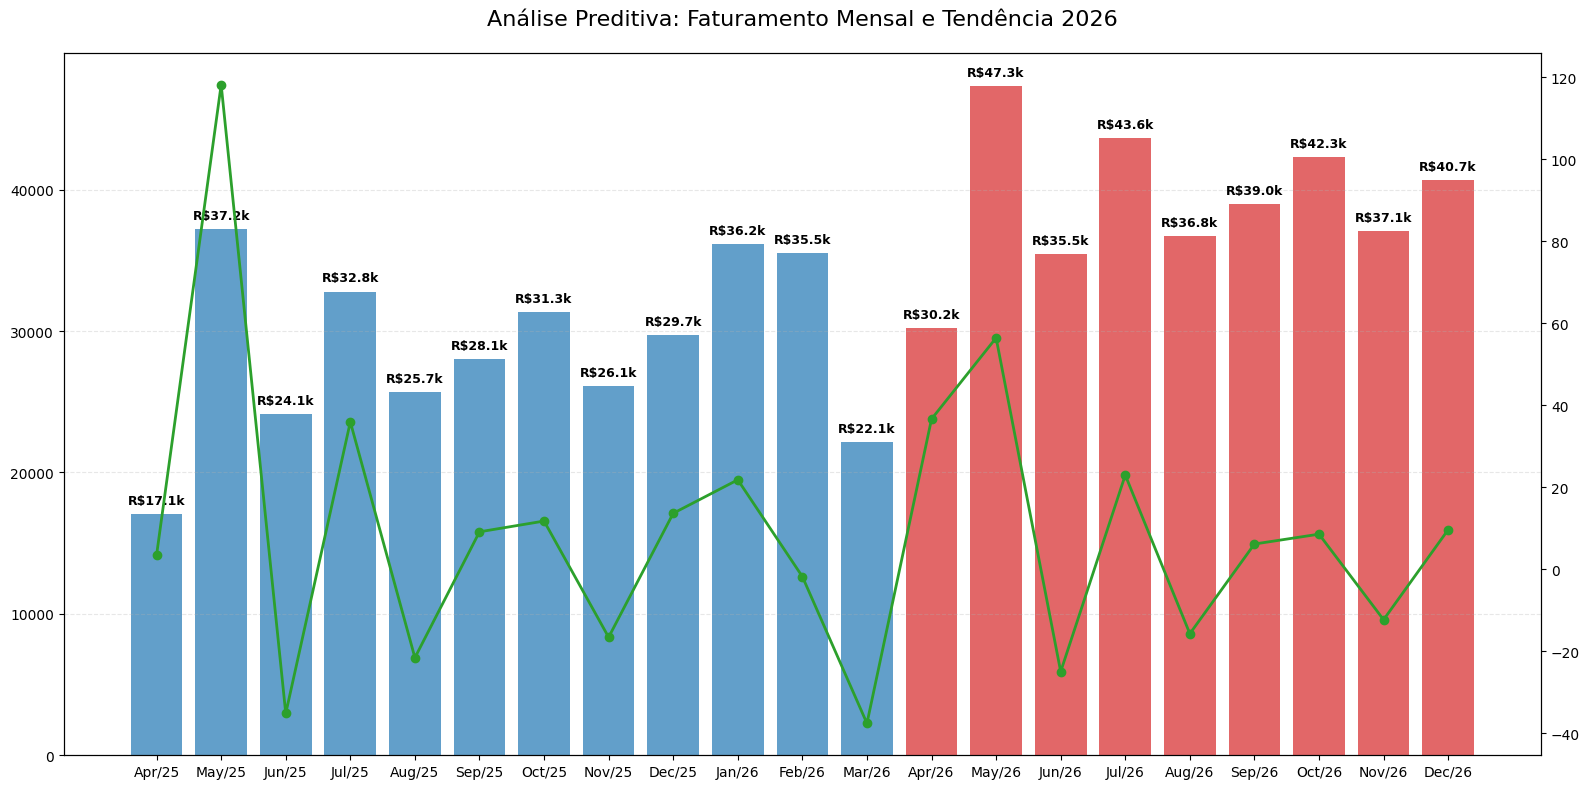

In [0]:
# PLOTAGEM DO GRÁFICO 
fig, ax1 = plt.subplots(figsize=(16, 8))
meses_labels = df_tabela_mensal['Período']
cores = ['#1f77b4' if t == 'Real' else '#d62728' for t in df_tabela_mensal['tipo']]

bars = ax1.bar(meses_labels, df_tabela_mensal['faturamento'], color=cores, alpha=0.7)
ax2 = ax1.twinx()
ax2.plot(meses_labels, df_tabela_mensal['variacao_pct'], color='#2ca02c', marker='o', lw=2)

# Rótulos nas barras
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 500, f'R${height/1000:.1f}k', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Análise Preditiva: Faturamento Mensal e Tendência 2026', fontsize=16, pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [0]:

# 1. Extraindo Sazonalidade do df_final (Médias Históricas)
df_sazonal_bruto = df_final.groupBy("mes") \
    .agg(F.avg("faturamento").alias("faturamento_medio")) \
    .toPandas()

nomes_meses = {1: "Janeiro", 2: "Fevereiro", 3: "Março", 4: "Abril", 5: "Maio", 6: "Junho",
               7: "Julho", 8: "Agosto", 9: "Setembro", 10: "Outubro", 11: "Novembro", 12: "Dezembro"}
df_sazonal_bruto['mes_nome'] = df_sazonal_bruto['mes'].map(nomes_meses)

# Identificação de Picos e Baixas (Ordenação por Valor para extrair os meses)
df_ord_valor = df_sazonal_bruto.sort_values(by='faturamento_medio', ascending=False)

# Criando as listas e ordenando-as pelo NÚMERO do mês (Cronológica)
maiores_meses = df_ord_valor.head(3).sort_values(by='mes')['mes_nome'].tolist()
menores_meses = df_ord_valor.tail(3).sort_values(by='mes')['mes_nome'].tolist()

# 2. Identificação de Picos e Alavancas (Aproveitando df_estilo e df_motivos_perda)
top_estilo_val = df_estilo.first() 
pior_motivo_val = df_motivos_perda.first()

# 3. Extraindo a Taxa de Conversão Real do df_funil
linha_venda = df_funil.filter(F.col("resultado") == "Venda").first()
taxa_venda = linha_venda["taxa_conversao_pct"] if linha_venda else 0

# 4. Insights de Crescimento (Consumindo df_view e df_final)
faturam_2025 = df_final.filter(F.col("ano") == 2025).agg(F.sum("faturamento")).collect()[0][0]
faturam_proj_2026 = df_view[df_view.index.year == 2026]['faturamento'].sum()
crescimento_anual_est = ((faturam_proj_2026 / faturam_2025) - 1) * 100

print("=" * 85)
print(" ENGINE DE INSIGHTS: DIAGNÓSTICO ESTRATÉGICO FINAL")
print("=" * 85)

# --- SEÇÃO 1: COMPORTAMENTO E SAZONALIDADE ---
print(f" SAZONALIDADE ALTA: Os meses com maior faturamento médio são: {', '.join(maiores_meses)}.")
print(f" SAZONALIDADE BAIXA: Os períodos com menor faturamento médio são: {', '.join(menores_meses)}.")
print(f" PRODUTO: O estilo '{top_estilo_val['estilo']}' domina {top_estilo_val['pct_faturamento']}% da receita.")

# --- SEÇÃO 2: EFICIÊNCIA COMERCIAL ---
print("-" * 85)
print(f" CONVERSÃO: Sua taxa de conversão atual (Leads -> Vendas) é de {taxa_venda}%.")
print(f" GARGALO: A perda principal é por '{pior_motivo_val['motivo_nao_venda']}' ({pior_motivo_val['pct_ocorrencias']}% das perdas).")

# --- SEÇÃO 3: FORECAST E METAS ---
print("-" * 85)
print(f" META 2026: Projeção de faturamento total acumulado de R$ {faturam_proj_2026/1000:.1f}k.")
print(f" PERFORMANCE: Crescimento anual estimado em {crescimento_anual_est:.1f}% (2026 vs 2025).")
print("=" * 85)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


 ENGINE DE INSIGHTS: DIAGNÓSTICO ESTRATÉGICO FINAL
 SAZONALIDADE ALTA: Os meses com maior faturamento médio são: Julho, Setembro, Novembro.
 SAZONALIDADE BAIXA: Os períodos com menor faturamento médio são: Março, Abril, Junho.
 PRODUTO: O estilo 'Realismo preto e cinza' domina 41.91% da receita.
-------------------------------------------------------------------------------------
 CONVERSÃO: Sua taxa de conversão atual (Leads -> Vendas) é de 7.0%.
 GARGALO: A perda principal é por 'Sem retorno' (45.65% das perdas).
-------------------------------------------------------------------------------------
 META 2026: Projeção de faturamento total acumulado de R$ 446.3k.
 PERFORMANCE: Crescimento anual estimado em 43.7% (2026 vs 2025).
